# Week 4: Data Quality and Product Distribution

This notebook explores the cleaned 2024 CFPB modeling dataset before baseline model training.

Scope rules:

- Use only `data/processed/cfpb_complaints_2024_cleaned.csv`.
- Do not use the 2025 holdout dataset.
- Do not train models or create model scores.
- Do not create confusion matrices, classification reports, or routing confidence outputs.
- Save only aggregate charts and summary notes.

## Imports and Project Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def find_project_root(start_path):
    """Find the project root from either the repository root or the notebooks folder."""
    current_path = start_path.resolve()
    for candidate_path in [current_path, *current_path.parents]:
        expected_data_path = candidate_path / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"
        if expected_data_path.exists():
            return candidate_path
    raise FileNotFoundError("Could not find data/processed/cfpb_complaints_2024_cleaned.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PRODUCT_DISTRIBUTION_PATH = FIGURES_DIR / "product_distribution.png"
TEXT_LENGTH_DISTRIBUTION_PATH = FIGURES_DIR / "text_length_distribution.png"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Product chart path: {PRODUCT_DISTRIBUTION_PATH.relative_to(PROJECT_ROOT)}")
print(f"Text length chart path: {TEXT_LENGTH_DISTRIBUTION_PATH.relative_to(PROJECT_ROOT)}")

Project root: <project-root>
Dataset path: data\processed\cfpb_complaints_2024_cleaned.csv
Product chart path: reports\figures\product_distribution.png
Text length chart path: reports\figures\text_length_distribution.png


## Load Cleaned 2024 Dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Row count: {len(df):,}")
print(f"Column names: {list(df.columns)}")

Row count: 50,000
Column names: ['clean_complaint_text', 'product']


## Required Column Checks

In [4]:
required_columns = ["clean_complaint_text", "product"]
missing_required_columns = [column for column in required_columns if column not in df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

print(f"Required columns present: {required_columns}")

Required columns present: ['clean_complaint_text', 'product']


## Basic Data Quality Checks

In [5]:
row_count = len(df)
column_names = list(df.columns)
unique_product_categories = df["product"].nunique(dropna=True)
duplicate_row_count = int(df.duplicated().sum())
missing_clean_text_count = int(df["clean_complaint_text"].isna().sum())
missing_product_count = int(df["product"].isna().sum())
empty_clean_text_count = int(df["clean_complaint_text"].fillna("").astype(str).str.strip().eq("").sum())

print(f"Row count: {row_count:,}")
print(f"Column names: {column_names}")
print(f"Number of unique product categories: {unique_product_categories:,}")
print(f"Duplicate row count: {duplicate_row_count:,}")
print(f"Missing clean_complaint_text count: {missing_clean_text_count:,}")
print(f"Missing product count: {missing_product_count:,}")
print(f"Empty cleaned text count: {empty_clean_text_count:,}")

Row count: 50,000
Column names: ['clean_complaint_text', 'product']
Number of unique product categories: 11
Duplicate row count: 16,006
Missing clean_complaint_text count: 0
Missing product count: 0
Empty cleaned text count: 0


## Product Category Distribution

In [6]:
product_distribution = (
    df["product"]
    .value_counts()
    .rename_axis("product")
    .reset_index(name="count")
)
product_distribution["percentage"] = (product_distribution["count"] / row_count * 100).round(2)

print(product_distribution.to_string(index=False))

                                                product  count  percentage
    Credit reporting or other personal consumer reports  36128       72.26
                                        Debt collection   5357       10.71
                                            Credit card   2735        5.47
                            Checking or savings account   2146        4.29
                                               Mortgage    887        1.77
     Money transfer, virtual currency, or money service    725        1.45
                                           Student loan    628        1.26
                                  Vehicle loan or lease    590        1.18
Payday loan, title loan, personal loan, or advance loan    363        0.73
                                           Prepaid card    317        0.63
                              Debt or credit management    124        0.25


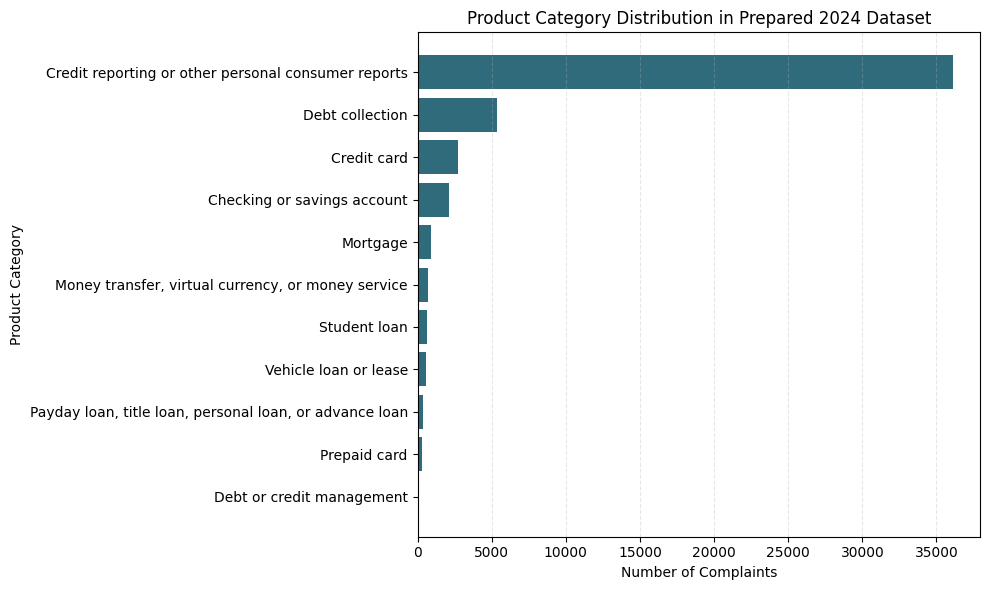

Saved chart to: reports\figures\product_distribution.png


In [7]:
figure_height = max(6, 0.45 * len(product_distribution))
fig, ax = plt.subplots(figsize=(10, figure_height))

ax.barh(product_distribution["product"], product_distribution["count"], color="#2f6b7a")
ax.invert_yaxis()
ax.set_title("Product Category Distribution in Prepared 2024 Dataset")
ax.set_xlabel("Number of Complaints")
ax.set_ylabel("Product Category")
ax.grid(axis="x", linestyle="--", alpha=0.3)

fig.tight_layout()
fig.savefig(PRODUCT_DISTRIBUTION_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {PRODUCT_DISTRIBUTION_PATH.relative_to(PROJECT_ROOT)}")

## Complaint Text Length Analysis

In [8]:
clean_text = df["clean_complaint_text"].fillna("").astype(str)

text_length_features = pd.DataFrame(
    {
        "character_length": clean_text.str.len(),
        "word_count": clean_text.str.split().str.len(),
    }
)

text_length_summary = text_length_features.describe().round(2)
print(text_length_summary.to_string())

       character_length  word_count
count          50000.00    50000.00
mean            1051.42      182.13
std             1455.82      250.61
min               10.00        1.00
25%              305.00       53.00
50%              679.00      117.00
75%             1275.00      224.00
max            32550.00     5853.00


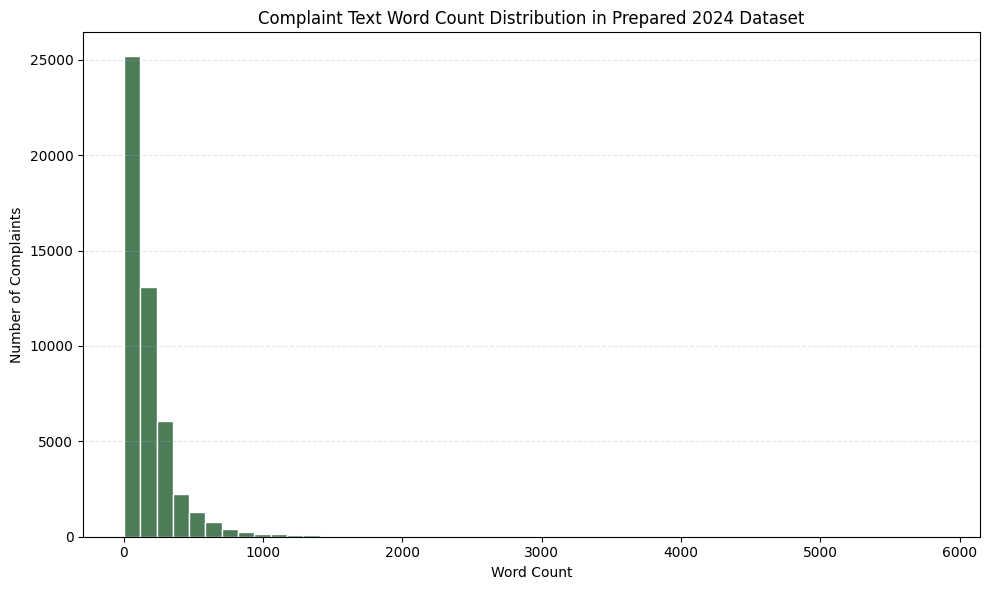

Saved chart to: reports\figures\text_length_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(text_length_features["word_count"], bins=50, color="#4d7c59", edgecolor="white")
ax.set_title("Complaint Text Word Count Distribution in Prepared 2024 Dataset")
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Complaints")
ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout()
fig.savefig(TEXT_LENGTH_DISTRIBUTION_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {TEXT_LENGTH_DISTRIBUTION_PATH.relative_to(PROJECT_ROOT)}")

## Week 4 Summary and Modeling Scope Recommendation

The cleaned 2024 modeling dataset contains 50,000 rows and the required columns `clean_complaint_text` and `product`. The required fields are complete: there are 0 missing complaint texts, 0 missing product labels, and 0 empty cleaned complaint texts. The dataset contains 16,006 duplicate rows, which should be considered during future train, validation, and test splitting to reduce leakage risk.

The product distribution is highly imbalanced. `Credit reporting or other personal consumer reports` represents 72.26% of the prepared 2024 dataset, while several product categories each represent less than 2% of records.

Because the product distribution is highly imbalanced, Version 1 should focus on the strongest/top product categories first, while keeping the full cleaned 2024 dataset local for later experiments. The 2025 dataset was later evaluated once under the committed protocol in Notebook 07 and is now exhausted as an unbiased holdout; it must remain separate from future model development and tuning.